In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.ticker as mtick
# import matplotlib as mpl

import scienceplots
# plt.style.use(['science', 'vibrant'])
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 8
plt.rcParams.update({'font.size': 10})
colors = plt.colormaps['tab20']

from src import *

In [4]:
prev = 0.5
sp.special.logit(prev)

np.float64(0.0)

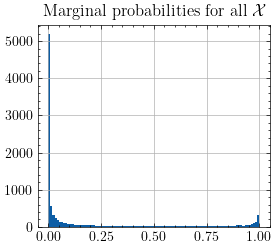

In [ ]:
# Dice loss function on binary numbers
dice_loss = lambda y, y_hat: 1 - 2 * bin(y & y_hat).count("1") / (bin(y).count("1") + bin(y_hat).count("1") + 1e-3)

# number of pixels
n = 10

loc = -3

# marginal probabilities
Pyi = np.array([sp.special.expit(np.random.RandomState(x).normal(loc,scale=5,size=n)) for x in range(2**n)])

# image-level output probability derived from pixel-level probabilities
def get_Py_x(y, x, Pyi=Pyi):
    y_probs = np.where([yi == '1' for yi in np.binary_repr(y, width=n)], Pyi[x], 1 - Pyi[x])
    return np.prod(y_probs)

plt.hist(Pyi.flatten(), bins=np.linspace(0,1,100))
# plt.yscale('log')
plt.title("Marginal probabilities for all $\mathcal{X}$")
plt.show()

In [16]:
sum([get_Py_x(y, 42, Pyi) for y in np.arange(2**n)])

np.float64(1.0)

In [ ]:
# image-level output probability derived from pixel-level probabilities
def get_Py_x_(y, x, Pyi=Pyi):
    y_probs = np.where([yi == '1' for yi in np.binary_repr(y, width=n)], Pyi[x], 1 - Pyi[x])
    return np.prod(y_probs)

sum([get_Py_x(y, 42, Pyi) for y in np.arange(1,2**n)])

np.float64(0.9999999998660876)

In [17]:
sum([get_Py_x(y, 42, Pyi) for y in np.arange(1,2**n)])

np.float64(0.9993152870890274)

In [18]:
Y = np.vectorize(lambda x: np.sum((2**np.arange(n)[::-1]) * (np.random.RandomState(x+1).rand(n) < Pyi[x])))(np.arange(2**n))
Y.shape

(1024,)

In [29]:
np.mean([np.bitwise_count(y) for y in Y]) / 10

np.float64(0.19052734375)

In [31]:
sp.special.expit(sp.special.logit(f))

np.float64(0.010000000000000002)

In [33]:
np.mean(Pyi)

np.float64(0.19253323394465355)

In [199]:
sp.special.expit(np.random.normal(-3,scale=5,size=1000)).mean()

np.float64(0.3034359343835609)

In [34]:
np.random.normal(sp.special.logit(f),scale=5,size=n)

array([ -3.78554231,  -5.76788303, -10.90675511,   1.60937189,
        -6.55226328,  -7.02404249,  -6.06672061, -16.61598169,
         0.1016597 ,  -3.05303169])

In [24]:
bin(Y[5])

'0b10010000'

## Ideal Model

Model is based on the actual marginals.

In [19]:
def SDC(y_hat, hatPyi):
    # y_hat_ = int2img(y_hat, n=n).flatten()
    # return 2 * (y_hat_ * hatPyi).sum() / (np.sum(y_hat_) + hatPyi.sum())
    tp = np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], hatPyi, 0).sum()
    return 2 * tp / (bin(y_hat).count("1") + hatPyi.sum())

def aMSP(y_hat, hatPyi):
    return np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], hatPyi, 1-hatPyi).mean()

In [20]:
h = lambda x: ((2**np.arange(n)[::-1]) * (Pyi[x] >= 0.5)).sum()

Y_pred = np.vectorize(h)(np.arange(2**n))

### True RC curve

Using the actual conditional risk, computed from the entire population ($\mathcal{X}$).

Avg. MSP =  0.09926470756920248
SDC =  0.08602580594796361
IDC =  0.08592938982759712


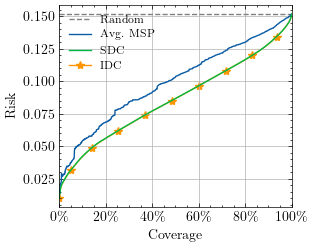

In [24]:
def r_y_x(y, x):
    y_pred = Y_pred[x]
    return dice_loss(y, y_pred) * get_Py_x(y, x)

def r(x):
    return np.vectorize(lambda y: r_y_x(y, x))(np.arange(2**n)).sum()
    y_pred = Y_pred[x]
    return np.vectorize(lambda y: dice_loss(y, y_pred) * get_Py_x(y, x))(np.arange(2**n)).sum()
    r_x = 0
    # for y in np.arange(2**n):
    #     r_x += dice_loss(y, y_hat) * get_Py_x(y, x)

    # return r_x

R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

idc_risks, idc_coverages = rc_curve_(R_x, -R_x)

plt.hlines(idc_risks[-1], 0, 1, linestyles='--', color='gray', label="Random")

risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_pred[x], Pyi[x]))(np.arange(2**n)))

print("Avg. MSP = ", auc(coverages, risks))
plt.plot(coverages, risks, label="Avg. MSP")

sdc_risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_pred[x], Pyi[x]))(np.arange(2**n)))

print("SDC = ", auc(coverages, sdc_risks))
plt.plot(coverages, sdc_risks, label="SDC")


print("IDC = ", auc(idc_coverages, idc_risks))
plt.plot(idc_coverages, idc_risks, marker="*", markevery=0.10, zorder=-1, label="IDC")

plt.legend()
plt.xlim(0,1)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.title("True risk - Ideal model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
# plt.savefig("true_rc_ideal_model.pdf")
plt.show()

In [25]:
(0.09926470756920248 - 0.08592938982759712) / 0.08592938982759712

0.15518925210990597

In [26]:
(0.08602580594796361 - 0.08592938982759712) / 0.08592938982759712

0.0011220389270763513

In [7]:
(0.07413651656681866 - 0.067501532046083) / 0.067501532046083

0.09829383600072936

In [27]:
(0.0675955628876738 - 0.067501532046083) / 0.067501532046083

0.0013930178877510151

### Sampled target

Instead of computing the actual conditional risk, we generate targets based on the marginal probabilities, and use that to estimate the risk.

In [6]:
Y = np.vectorize(lambda x: np.sum((2**np.arange(n)[::-1]) * (np.random.RandomState(x+1).rand(n) < Pyi[x])))(np.arange(2**n))

print("Mean dice score = ", 1 - np.vectorize(dice_loss)(Y_pred, Y).mean())

Mean dice score =  0.8773690442927737


Avg. MSP =  0.07274826327041747
SDC =  0.06629121651536737
IDC =  0.0664248598326321
Oracle =  0.03570636315662705


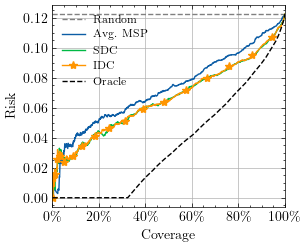

In [ ]:
errors = np.vectorize(dice_loss)(Y_pred, Y)
oracle_risks, oracle_coverages = rc_curve_(errors, -errors)

plt.hlines(oracle_risks[-1], 0, 1, linestyles='--', colors='grey', label="Random")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: aMSP(Y_pred[x], Pyi[x]))(np.arange(2**n)))

print("Avg. MSP = ", auc(coverages, risks))
plt.plot(coverages, risks, label="Avg. MSP")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: SDC(Y_pred[x], Pyi[x]))(np.arange(2**n)))

print("SDC = ", auc(coverages, risks))
plt.plot(coverages, risks, label="SDC")

risks, coverages = rc_curve_(errors, -R_x)

print("IDC = ", auc(coverages, risks))
plt.plot(coverages, risks, marker="*", markevery=0.10, zorder=-1, label="IDC")

print("Oracle = ", auc(oracle_coverages, oracle_risks))
plt.plot(oracle_coverages, oracle_risks, linestyle='--', color='black', label="Oracle")

plt.legend()
plt.xlim(0,1)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.title("Sampled test set - Ideal model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.savefig("sampled_rc_ideal_model.pdf")
plt.show()

In [11]:
(0.06629121651536737 - 0.0664248598326321) / 0.0664248598326321

-0.0020119472980668156

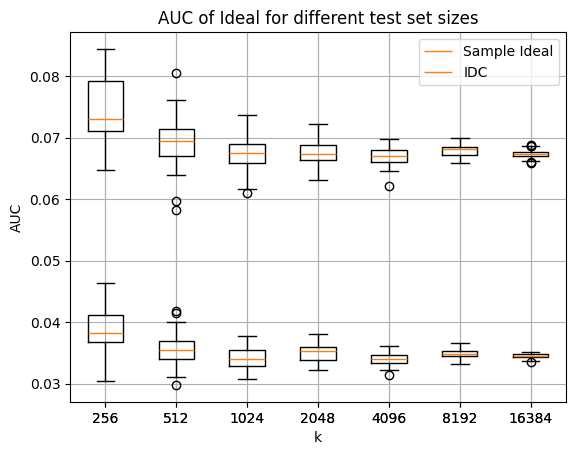

In [81]:
aucs_sample_ideal = dict()
aucs_idc = dict()
for k in 2**np.arange(8,15):
    aucs_sample_ideal[k] = []
    aucs_idc[k] = []
    X_sample = np.random.choice(2**n, k)
    Y_pred_test = np.vectorize(h)(X_sample)

    for _ in range(50):
        Y_test = np.vectorize(lambda x: np.sum((2**np.arange(n)[::-1]) * (np.random.rand(n) < Pyi[x])))(X_sample)
        assert len(Y_test) == k

        errors = np.vectorize(dice_loss)(Y_pred_test, Y_test)
        risks, coverages = rc_curve_(errors, -errors)

        aucs_sample_ideal[k].append(auc(coverages, risks))
 
        risks, coverages = rc_curve_(errors, -R_x[X_sample])
        aucs_idc[k].append(auc(coverages, risks))

plt.boxplot([aucs_sample_ideal[k] for k in aucs_sample_ideal.keys()], tick_labels=aucs_sample_ideal.keys(), label="Sample Ideal")
plt.boxplot([aucs_idc[k] for k in aucs_idc.keys()], tick_labels=aucs_idc.keys(), label="IDC")

# errors = np.vectorize(dice_loss)(Y_pred, Y)
# risks, coverages = rc_curve_(errors, -errors)
# xlim = plt.xlim()
# plt.hlines(auc(coverages, risks), 0, 2*k, label="Ideal from the curve")
# risks, coverages = rc_curve_(errors, -R_x)
# plt.hlines(auc(coverages, risks), 0, 2*k, color='red', label="True Risk")
# plt.xlim(xlim)

plt.xlabel('k')
plt.ylabel('AUC')
plt.legend()
plt.title('AUC of Ideal for different test set sizes')
plt.show()

In [87]:
(sum(aucs_idc[16384]) / 50) - (sum(aucs_sample_ideal[16384]) / 50)

np.float64(0.0328746392600521)

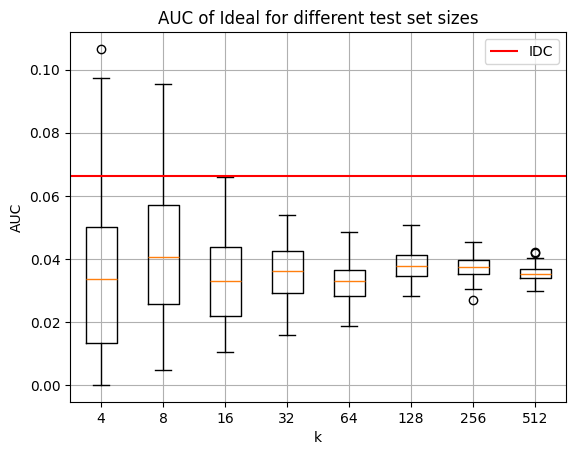

In [ ]:
aucs_sample_ideal = dict()
for k in 2**np.arange(2,10):
    aucs_sample_ideal[k] = []

    Pyi_test = np.array([sp.special.expit(np.random.normal(0,scale=5,size=n)) for x in range(k)])
    Y_pred_test = [((2**np.arange(n)[::-1]) * (Pyi_test[x] >= 0.5)).sum() for x in range(k)]

    for _ in range(50):
        Y_test = np.vectorize(lambda x: np.sum((2**np.arange(n)[::-1]) * (np.random.rand(n) < Pyi_test[x])))(np.arange(k))
        assert len(Y_test) == k

        errors = np.vectorize(dice_loss)(Y_pred_test, Y_test)
        risks, coverages = rc_curve_(errors, -errors)

        aucs_sample_ideal[k].append(auc(coverages, risks))

plt.boxplot([aucs_sample_ideal[k] for k in aucs_sample_ideal.keys()], tick_labels=aucs_sample_ideal.keys())

errors = np.vectorize(dice_loss)(Y_pred, Y)
xlim = plt.xlim()

# risks, coverages = rc_curve_(errors, -errors)
# plt.hlines(auc(coverages, risks), 0, 2*k, label="Sample Ideal")

risks, coverages = rc_curve_(errors, -R_x)
plt.hlines(auc(coverages, risks), 0, 2*k, color='red', label="IDC")
plt.xlim(xlim)

plt.xlabel('k')
plt.ylabel('AUC')
plt.legend()
plt.title('AUC of Ideal for different test set sizes')
plt.show()

In [23]:
def b_U(k, mu, lam, tol=1e-12):
    """
    Parameters:
        max_terms (int): Maximum number of terms to sum in the series.
        tol (float): Convergence tolerance.
    """
    numerator_constant = np.float128(k + k * mu + lam)  # Precompute numerator constant
    denominator_base = np.float128(k + k * mu)  # Precompute denominator base
    e_neg_lam = np.exp(-lam, dtype=np.float128)  # Precompute e^(-lambda)

    b_u_value = 0.0

    i = 0
    lam_to_the_i = lam ** 0
    cum_prob = 0
    poisson_term = e_neg_lam  # Poisson probability
    while True:
        fraction = numerator_constant / (denominator_base + i)  # Fraction term
        term = poisson_term * fraction  # Current term

        b_u_value += term
        cum_prob += poisson_term

        # Check for convergence
        # if term < tol:
        #     break
        if (cum_prob > 0.99) and (term < tol):
            break

        i += 1
        lam_to_the_i = lam_to_the_i * lam
        poisson_term = poisson_term * (lam / i)

    return b_u_value

def b_L(k, mu, lam):
    return (k + k*mu + lam) / (k + 1 + (k - 1)*mu + lam)

x = np.random.choice(2**n)

k = Y_pred[x].bit_count()
mu = np.where([yi_hat == '1' for yi_hat in np.binary_repr(Y_pred[x], width=n)], Pyi[x], 0).sum() / k
s0 = np.where([yi_hat == '0' for yi_hat in np.binary_repr(Y_pred[x], width=n)], Pyi[x], 0).sum()

b_L(k, mu, s0), b_U(k, mu, 1e3)
# b_U(100, 0.0, 1e4, tol=1e-6)

(np.float64(0.995855847509971),
 np.longdouble('1.0009716266072196572435967272965562'))

In [10]:
# k = np.unique(np.geomspace(1, 1000, 101)) #.astype(int))
# s0 = np.geomspace(0.1, 1000, 100)
# mus = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]

# k_, s0_ = np.meshgrid(k, s0)

# es = {}
# for mu in mus:
#     e = np.vectorize(lambda k, s0: b_U(k, mu, s0) - b_L(k, mu, s0))(k_, s0_)
#     es[mu] = e

# path = r'.'

# for i, mu in enumerate(mus):
#     e = es[mu]
#     levels = [np.round(e.max(), 4), 0.1, 0.01, 0.001, 0.0001][::-1]
#     plt.contourf(k_, s0_, np.log10(e), levels=np.log10(levels), vmax = np.log10(0.5), vmin=np.log10(1e-4), cmap='Blues')
#     cbar = plt.colorbar()
#     cbar.set_ticklabels(levels)
#     plt.contour(k_, s0_, e, levels=np.hstack([np.arange(1, 10)*a for a in [0.1, 0.01, 0.001, 0.0001][::-1]]), linewidths=0.5, colors='k')
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.ylim(0.1, 1000)
#     plt.xlabel('k')
#     plt.ylabel('$\lambda$')
#     plt.title(f'$\mu$ = {mu}')
#     plt.grid('on')
#     fig_id = f'{mu:.2f}'.replace('.','')
#     # plt.savefig(f'{path}/contour{fig_id}.pdf')
#     plt.show()

/tmp/ipykernel_25568/807791705.py:2: RuntimeWarning: invalid value encountered in scalar divide
  Mu = np.array([np.where([yi_pred == '1' for yi_pred in np.binary_repr(y_pred, width=n)], Pyi[x], 0).sum() / K[x] for x, y_pred in enumerate(Y_pred)])


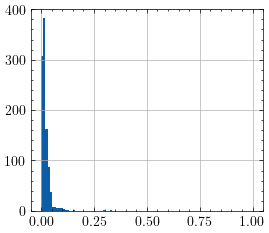

In [26]:
K = np.array([y_pred.bit_count() for y_pred in Y_pred])
Mu = np.array([np.where([yi_pred == '1' for yi_pred in np.binary_repr(y_pred, width=n)], Pyi[x], 0).sum() / K[x] for x, y_pred in enumerate(Y_pred)])
# Mu[np.isnan(Mu)] = 0
Lambda = np.array([np.where([yi_pred == '0' for yi_pred in np.binary_repr(y_pred, width=n)], Pyi[x], 0).sum() for x, y_pred in enumerate(Y_pred)])

bounds = np.vectorize(lambda k, mu, lam: b_U(k, mu, lam) - b_L(k, mu, lam))(K[K > 0], Mu[K > 0], Lambda[K > 0])

plt.hist(bounds, bins=np.linspace(0,1,100))
plt.show()

In [27]:
bounds.min(), bounds.mean(), bounds.max()

(np.longdouble('0.00077808681294992720909008791163576965'),
 np.longdouble('0.020326661940872812716597116820786656'),
 np.longdouble('0.3235547155616466186660660430448279'))

In [12]:
B_U = np.vectorize(b_U)(K[K > 0], Mu[K > 0], Lambda[K > 0])
np.any(B_U < 1.0)

np.False_

## Random Model

In [35]:
h_dummy = lambda x: np.random.RandomState(x+2).randint(0, 2**n)

print("Mean dice score = ", 1 - np.vectorize(lambda x: dice_loss(h_dummy(x), Y[x]))(Y).mean())

Mean dice score =  0.4739712532820113


## Non-ideal Model

Model is based on the actual marginals.

In [36]:
# pixel-level probability is predicted with a gaussian noise at the logits
def hatpyi(x, scale=2.0):
    z = sp.special.logit(Pyi[x])
    zhat = np.random.RandomState(x+33).normal(z, scale=scale)
    return sp.special.expit(zhat)

hatPyi = np.vstack([hatpyi(x) for x in np.arange(2**n)])

h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()

Y_hat = np.vectorize(h_hat)(np.arange(2**n))

### True RC curve

Using the actual conditional risk, computed from the entire population ($\mathcal{X}$).

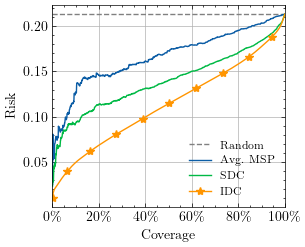

In [ ]:
def r(x):
    y_hat = Y_hat[x]
    return np.vectorize(lambda y: dice_loss(y, y_hat) * get_Py_x(y, x))(np.arange(2**n)).sum()

R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

idc_risks, idc_coverages = rc_curve_(R_x, -R_x)

plt.hlines(idc_risks[-1], 0, 1, linestyles='--', color='gray', label="Random")

risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="Avg. MSP")

risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="SDC")

plt.plot(idc_coverages, idc_risks, marker="*", markevery=0.10, label="IDC")

plt.legend()
plt.xlim(0,1)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.title("True risk - Noisy model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.savefig("true_rc_noisy_model.pdf")
plt.show()

### Sampled target

Instead of computing the actual conditional risk, we generate targets based on the marginal probabilities, and use that to estimate the risk.

In [37]:
print("Mean dice score = ", 1 - np.vectorize(dice_loss)(Y,Y_hat).mean())

Mean dice score =  0.8171384780126605


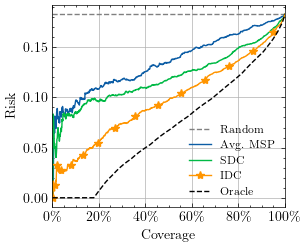

In [38]:
errors = np.vectorize(dice_loss)(Y, Y_hat)
R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

oracle_risks, oracle_coverages = rc_curve_(errors, -errors)

plt.hlines(oracle_risks[-1], 0, 1, linestyles='--', colors='grey', label="Random")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: aMSP(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="Avg. MSP")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="SDC")

risks, coverages = rc_curve_(errors, -R_x)

plt.plot(coverages, risks, marker="*", markevery=0.10, label="IDC")

plt.plot(oracle_coverages, oracle_risks, linestyle='--', color='black', label="Oracle")

plt.legend()
plt.xlim(0,1)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.title("Sampled test set - Noisy model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.savefig("sampled_rc_noisy_model.pdf")
plt.show()

### Bounds

/tmp/ipykernel_25568/563176863.py:2: RuntimeWarning: invalid value encountered in scalar divide
  Mu = np.array([np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], Pyi[x], 0).sum() / K[x] for x, y_hat in enumerate(Y_hat)])


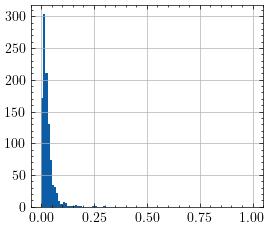

In [24]:
K = np.array([y_hat.bit_count() for y_hat in Y_hat])
Mu = np.array([np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], Pyi[x], 0).sum() / K[x] for x, y_hat in enumerate(Y_hat)])
# Mu[np.isnan(Mu)] = 0
Lambda = np.array([np.where([yi_hat == '0' for yi_hat in np.binary_repr(y_hat, width=n)], Pyi[x], 0).sum() for x, y_hat in enumerate(Y_hat)])

bounds = np.vectorize(lambda k, mu, lam: b_U(k, mu, lam) - b_L(k, mu, lam))(K[K > 0], Mu[K > 0], Lambda[K > 0])

plt.hist(bounds, bins=np.linspace(0,1,100))
plt.show()

In [25]:
bounds.min(), bounds.mean(), bounds.max()

(np.longdouble('0.00077808681294992720909008791163576965'),
 np.longdouble('0.029531981673681973614542870823923578'),
 np.longdouble('0.29344800645652387913442055640178137'))

# Progressive Perturbations

## True RC

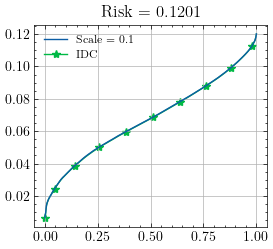

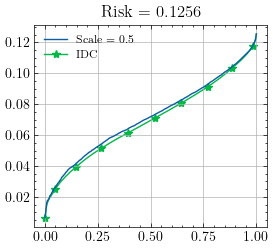

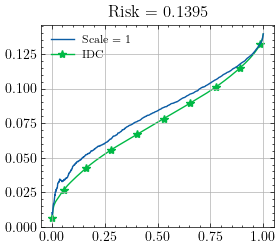

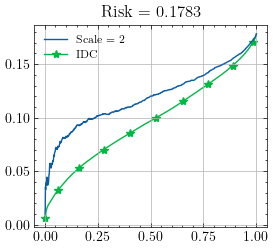

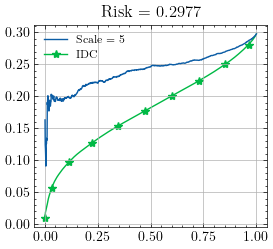

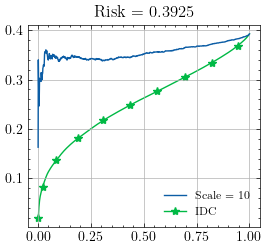

In [ ]:
for scale in [0.1, 0.5, 1, 2, 5, 10]:
    hatPyi = np.vstack([hatpyi(x, scale=scale) for x in np.arange(2**n)])
    h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()
    Y_hat = np.vectorize(h_hat)(np.arange(2**n))

    def r(x):
        y_hat = Y_hat[x]
        return np.vectorize(lambda y: dice_loss(y, y_hat) * get_Py_x(y, x))(np.arange(2**n)).sum()
    R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

    risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))
    plt.plot(coverages, risks, label=f"Scale = {scale}")

    idc_risks, idc_coverages = rc_curve_(R_x, -R_x)
    plt.plot(idc_coverages, idc_risks, marker="*", markevery=0.10, zorder=-1, label="IDC")

    plt.title(f"Risk = {risks[-1]:.4f}")
    plt.legend()
    plt.show()

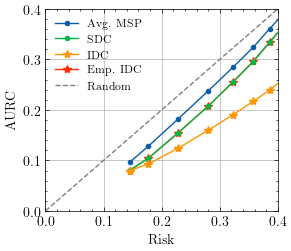

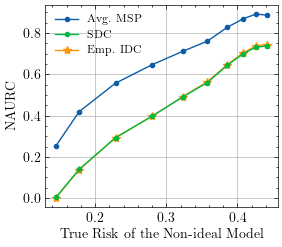

In [40]:
# risks = list()
# idc_aucs = list()
# hidc_aucs = list()
# sdc_aucs = list()
# msp_aucs = list()
# sdc_naurcs = list()
# msp_naurcs = list()
# hidc_naurcs = list()
# for scale in np.linspace(0.1, 10, 10):
#     hatPyi = np.vstack([hatpyi(x, scale=scale) for x in np.arange(2**n)])
#     h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()
#     Y_hat = np.vectorize(h_hat)(np.arange(2**n))

#     def r(x):
#         y_hat = Y_hat[x]
#         return np.vectorize(lambda y: dice_loss(y, y_hat) * get_Py_x(y, x))(np.arange(2**n)).sum()
#     R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

#     sdc_risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))
#     sdc_auc = auc(coverages, sdc_risks)
#     sdc_aucs.append(sdc_auc)

#     msp_risks, msp_coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_hat[x], hatPyi[x]))(np.arange(2**n)))
#     msp_auc = auc(msp_coverages, msp_risks)
#     msp_aucs.append(msp_auc)

#     idc_risks, idc_coverages = rc_curve_(R_x, -R_x)
#     idc_auc = auc(idc_coverages, idc_risks)
#     idc_aucs.append(idc_auc)

#     def hat_r(x):
#         y_hat = Y_hat[x]
#         return np.vectorize(lambda y: dice_loss(y, y_hat) * get_Py_x(y, x, Pyi=hatPyi))(np.arange(2**n)).sum()
#     hat_R_x = np.vectorize(hat_r)(np.arange(2**n))  # conditional risk

#     hidc_risks, hidc_coverages = rc_curve_(R_x, -hat_R_x)
#     hidc_auc = auc(hidc_coverages, hidc_risks)
#     hidc_aucs.append(hidc_auc)

#     random_risk = idc_risks[-1]
#     risks.append(random_risk)

#     sdc_naurc = (sdc_auc - idc_auc) / (random_risk - idc_auc)
#     sdc_naurcs.append(sdc_naurc)

#     msp_naurc = (msp_auc - idc_auc) / (random_risk - idc_auc)
#     msp_naurcs.append(msp_naurc)

#     hidc_naurc = (hidc_auc - idc_auc) / (random_risk - idc_auc)
#     hidc_naurcs.append(hidc_naurc)

plt.plot(risks, msp_aucs, marker=".", label="Avg. MSP")
plt.plot(risks, sdc_aucs, marker=".", label="SDC")
plt.plot(risks, idc_aucs, marker="*", label="IDC")
plt.plot(risks, hidc_aucs, marker="*", zorder=-1, label="Emp. IDC")
plt.plot([0,1], [0,1], '--', c='grey', label="Random")
plt.xlim(0, 0.4)
plt.ylim(0, 0.4)
plt.xlabel("Risk")
plt.ylabel("AURC")
plt.legend()
plt.savefig("aurc_risk.pdf")
plt.show()

plt.plot(risks, msp_naurcs, marker=".", label="Avg. MSP")
plt.plot(risks, sdc_naurcs, marker=".", label="SDC")
plt.plot(risks, hidc_naurcs, marker="*", zorder=-1, label="Emp. IDC")
plt.xlabel("True Risk of the Non-ideal Model")
plt.ylabel("NAURC")
plt.legend()
plt.show()

## Sampled target

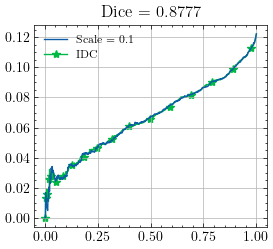

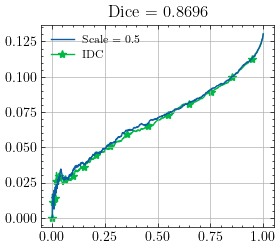

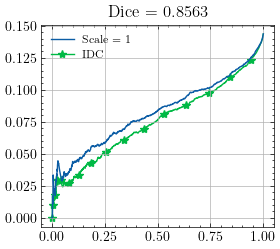

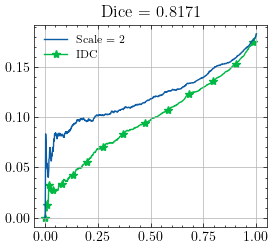

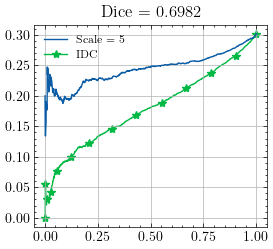

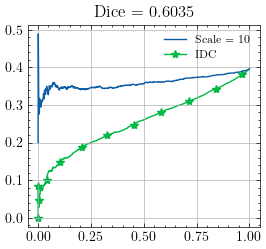

In [45]:
for scale in [0.1, 0.5, 1, 2, 5, 10]:
    hatPyi = np.vstack([hatpyi(x, scale=scale) for x in np.arange(2**n)])
    h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()
    Y_hat = np.vectorize(h_hat)(np.arange(2**n))

    def r(x):
        y_hat = Y_hat[x]
        return np.vectorize(lambda y: dice_loss(y, y_hat) * get_Py_x(y, x))(np.arange(2**n)).sum()
    R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

    errors = np.vectorize(dice_loss)(Y, Y_hat)

    risks, coverages = rc_curve_(errors, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))
    plt.plot(coverages, risks, label=f"Scale = {scale}")

    idc_risks, idc_coverages = rc_curve_(errors, -R_x)
    plt.plot(idc_coverages, idc_risks, marker="*", markevery=0.10, zorder=-1, label="IDC")

    mean_dice = 1 - np.vectorize(dice_loss)(Y,Y_hat).mean()
    plt.title(f"Dice = {mean_dice:.4f}")
    plt.legend()
    plt.show()

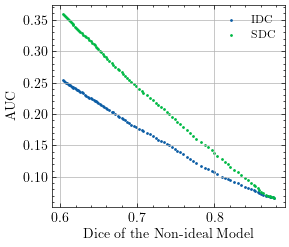

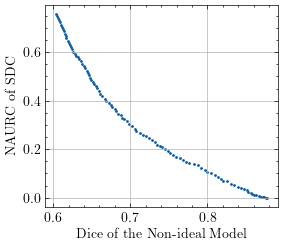

In [65]:
# dices = list()
# idc_aucs = list()
# sdc_aucs = list()
# naurcs = list()
# for scale in np.linspace(0.1, 10, 100):
#     hatPyi = np.vstack([hatpyi(x, scale=scale) for x in np.arange(2**n)])
#     h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()
#     Y_hat = np.vectorize(h_hat)(np.arange(2**n))

#     def r(x):
#         y_hat = Y_hat[x]
#         return np.vectorize(lambda y: dice_loss(y, y_hat) * get_Py_x(y, x))(np.arange(2**n)).sum()
#     R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

#     errors = np.vectorize(dice_loss)(Y, Y_hat)

#     risks, coverages = rc_curve_(errors, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))
#     sdc_auc = auc(coverages, risks)
#     sdc_aucs.append(sdc_auc)

#     idc_risks, idc_coverages = rc_curve_(errors, -R_x)
#     idc_auc = auc(idc_coverages, idc_risks)
#     idc_aucs.append(idc_auc)

#     mean_dice = 1 - np.vectorize(dice_loss)(Y,Y_hat).mean()
#     dices.append(mean_dice)

#     naurc = (sdc_auc - idc_auc) / (random_risk - idc_auc)
#     naurcs.append(naurc)

plt.scatter(dices, idc_aucs, s=1, label="IDC")
plt.scatter(dices, sdc_aucs, s=1, label="SDC")
plt.xlabel("Dice of the Non-ideal Model")
plt.ylabel("AUC")
plt.legend()
plt.show()

plt.scatter(dices, naurcs, s=1)
plt.xlabel("Dice of the Non-ideal Model")
plt.ylabel("NAURC of SDC")
plt.show()